<a href="https://colab.research.google.com/github/anarghasunil2014-eng/My-projects-in-RNN/blob/main/Classification%20of%20dogs%20and%20cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import os
from PIL import Image

IMG_SIZE = 64

X = []
y = []

# Dogs
for file in os.listdir("dogs"):
    file_path = os.path.join("dogs", file)
    if os.path.isfile(file_path): # Check if it's a file
        img = Image.open(file_path)
        img = img.convert("L")
        img = img.resize((IMG_SIZE,IMG_SIZE))

        X.append(np.array(img)/255.0)
        y.append(1)

# Cats
for file in os.listdir("cats"):
    file_path = os.path.join("cats", file)
    if os.path.isfile(file_path): # Check if it's a file
        img = Image.open(file_path)
        img = img.convert("L")
        img = img.resize((IMG_SIZE,IMG_SIZE))

        X.append(np.array(img)/255.0)
        y.append(0)

X = np.array(X)
y = np.array(y)

In [29]:
filter_size = 3
num_filters = 2

filters = np.random.randn(
    num_filters,
    filter_size,
    filter_size
)*0.1

fc_input = 31*31*num_filters

W_fc = np.random.randn(
    1,
    fc_input
)*0.1

b_fc = np.zeros((1,1))

In [30]:
def convolution(image,filt):

    h,w = image.shape

    f = filt.shape[0]

    output = np.zeros(
        (h-f+1,w-f+1)
    )

    for i in range(h-f+1):
        for j in range(w-f+1):

            region = image[
                i:i+f,
                j:j+f
            ]

            output[i,j] = np.sum(
                region*filt
            )

    return output

In [31]:
def relu(x):
    return np.maximum(0,x)

In [33]:
def maxpool(feature):

    h,w = feature.shape

    output = np.zeros(
        (h//2,w//2)
    )

    for i in range(0,h,2):
        for j in range(0,w,2):

            output[i//2,j//2] = np.max(
                feature[i:i+2,j:j+2]
            )

    return output

In [34]:
def forward(image):

    conv_maps = []

    for filt in filters:

        conv = convolution(
            image,
            filt
        )

        conv = relu(conv)

        pooled = maxpool(conv)

        conv_maps.append(pooled)

    feature_maps = np.array(conv_maps)

    flat = feature_maps.flatten()

    z = W_fc @ flat.reshape(-1,1)

    z += b_fc

    y_hat = 1/(1+np.exp(-z))

    return feature_maps,flat,y_hat

In [36]:
learning_rate = 0.001

epochs = 500

for epoch in range(epochs):

    total_loss = 0

    for image,label in zip(X,y):

        feature_maps,flat,y_hat = \
            forward(image)

        target = np.array([[label]])

        loss = 0.5*np.sum(
            (y_hat-target)**2
        )

        total_loss += loss

        dy = y_hat-target

        dW_fc = dy @ flat.reshape(1,-1)

        db_fc = dy

        W_fc -= learning_rate*dW_fc

        b_fc -= learning_rate*db_fc

    if epoch%10==0:

        print(
        "Epoch",
        epoch,
        "Loss",
        total_loss
        )

Epoch 0 Loss 2.555399940737461
Epoch 10 Loss 2.4991833139451027
Epoch 20 Loss 2.4497239430657247
Epoch 30 Loss 2.4013805047667978
Epoch 40 Loss 2.3545357686500594
Epoch 50 Loss 2.3093879640177053
Epoch 60 Loss 2.2659361236315245
Epoch 70 Loss 2.224114276105444
Epoch 80 Loss 2.1838405555606593
Epoch 90 Loss 2.1450319799085142
Epoch 100 Loss 2.1076086470990876
Epoch 110 Loss 2.071494835737303
Epoch 120 Loss 2.036619198618862
Epoch 130 Loss 2.002914681460816
Epoch 140 Loss 1.9703183528176842
Epoch 150 Loss 1.9387712031122337
Epoch 160 Loss 1.908217933197342
Epoch 170 Loss 1.878606741222288
Epoch 180 Loss 1.8498891124626118
Epoch 190 Loss 1.8220196149646324
Epoch 200 Loss 1.794955702843719
Epoch 210 Loss 1.7686575284044288
Epoch 220 Loss 1.7430877637685507
Epoch 230 Loss 1.7182114323416116
Epoch 240 Loss 1.6939957501863685
Epoch 250 Loss 1.6704099771811562
Epoch 260 Loss 1.6474252777052838
Epoch 270 Loss 1.6250145905003457
Epoch 280 Loss 1.6031525072952917
Epoch 290 Loss 1.5818151597465815

In [37]:
correct = 0

for image,label in zip(X,y):

    _,_,pred = forward(image)

    pred_class = 1 if pred>0.5 else 0

    if pred_class == label:
        correct += 1

accuracy = correct/len(X)

print(
    "Accuracy =",
    accuracy*100,
    "%"
)

Accuracy = 90.9090909090909 %


In [39]:
img = Image.open("testdog.jpg")
img = img.convert("L")
img = img.resize((64,64))

test = np.array(img)/255.0

_,_,pred = forward(test)

print("Probability =", pred[0,0])

if pred > 0.5:
    print("DOG")
else:
    print("CAT")

Probability = 0.6190683552980748
DOG


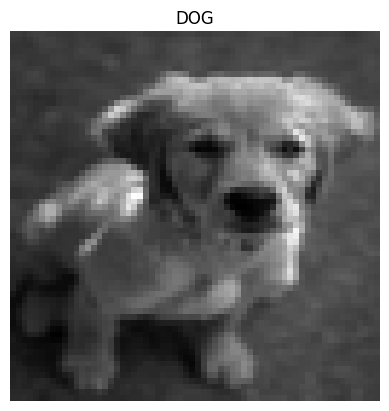

In [40]:
plt.imshow(test,cmap='gray')
plt.title(
    "DOG" if pred>0.5 else "CAT"
)
plt.axis('off')
plt.show()